In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df = pd.read_csv("../data/3_health_tech.csv")
df.head()

,imc,presion_sistolica,presion_diastolica,glucosa_ayunas,insulina,pliegue_cutaneo,edad,actividad_fisica_min,antecedentes_fam,colesterol_ldl,consumo_tabaco,target_diagnostico
0,23.867559,155.704221,77.013122,127.039115,86.954174,31.097285,82,481,0,54.158837,Fumador,Diabetes
1,19.616958,121.708332,83.190195,122.956413,233.947165,23.123609,42,92,0,78.918441,Fumador,Prediabetes
2,22.387818,119.480211,90.131034,117.451843,68.647696,27.466431,61,252,0,117.295299,Fumador,Sano
3,26.181400,120.664882,85.043992,138.380702,113.680853,17.937067,62,560,1,104.453259,Ex-fumador,Diabetes
4,21.932443,123.372741,72.855280,148.590359,240.480995,28.041270,74,38,1,108.800789,Ex-fumador,Sano


In [3]:
df_modelo = df.copy()

df_modelo["consumo_tabaco"] = df_modelo["consumo_tabaco"].map({
    "Nunca": 0,
    "Ex-fumador": 1,
    "Fumador": 2
})

label_encoder = LabelEncoder()
df_modelo["target_diagnostico"] = label_encoder.fit_transform(df_modelo["target_diagnostico"])

df_modelo.head()

,imc,presion_sistolica,presion_diastolica,glucosa_ayunas,insulina,pliegue_cutaneo,edad,actividad_fisica_min,antecedentes_fam,colesterol_ldl,consumo_tabaco,target_diagnostico
0,23.867559,155.704221,77.013122,127.039115,86.954174,31.097285,82,481,0,54.158837,2,0
1,19.616958,121.708332,83.190195,122.956413,233.947165,23.123609,42,92,0,78.918441,2,1
2,22.387818,119.480211,90.131034,117.451843,68.647696,27.466431,61,252,0,117.295299,2,2
3,26.181400,120.664882,85.043992,138.380702,113.680853,17.937067,62,560,1,104.453259,1,0
4,21.932443,123.372741,72.855280,148.590359,240.480995,28.041270,74,38,1,108.800789,1,2


In [4]:
X = df_modelo.drop("target_diagnostico", axis=1)
y = df_modelo["target_diagnostico"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases codificadas:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Shape de X: (1200, 11)
Shape de y: (1200,)
Clases codificadas: {'Diabetes': np.int64(0), 'Prediabetes': np.int64(1), 'Sano': np.int64(2)}


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (960, 11)
Prueba: (240, 11)


In [6]:
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)

print("Modelo de árbol entrenado correctamente.")

Modelo de árbol entrenado correctamente.


In [7]:
y_pred_arbol = modelo_arbol.predict(X_test)

accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
print("Accuracy Árbol de Decisión:", accuracy_arbol)

Accuracy Árbol de Decisión: 0.32916666666666666


In [8]:
print("Reporte de clasificación - Árbol de Decisión:\n")
print(classification_report(y_test, y_pred_arbol, target_names=label_encoder.classes_))

Reporte de clasificación - Árbol de Decisión:

              precision    recall  f1-score   support

    Diabetes       0.34      0.27      0.30        78
 Prediabetes       0.27      0.20      0.23        80
        Sano       0.35      0.51      0.42        82

    accuracy                           0.33       240
   macro avg       0.32      0.33      0.32       240
weighted avg       0.32      0.33      0.32       240



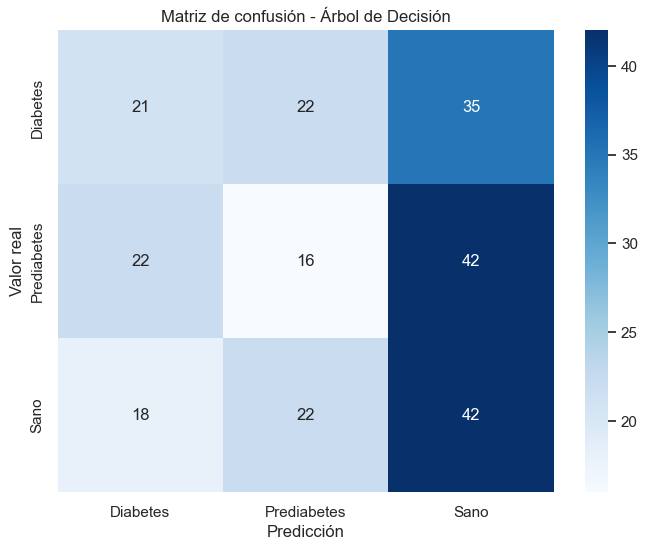

In [9]:
matriz_arbol = confusion_matrix(y_test, y_pred_arbol)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_arbol,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Matriz de confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

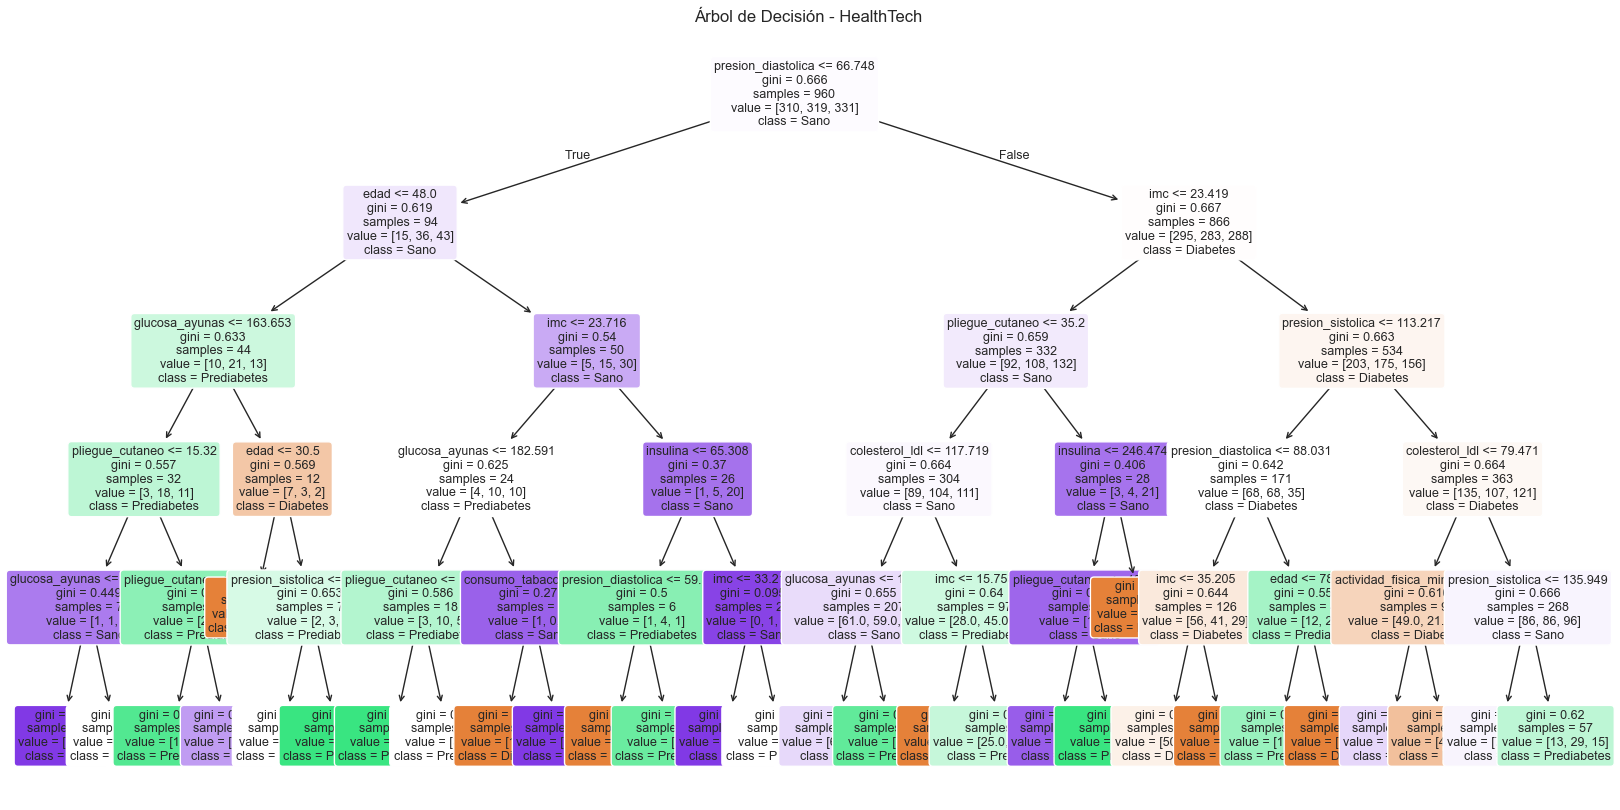

In [10]:
plt.figure(figsize=(20, 10))
tree.plot_tree(
    modelo_arbol,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Árbol de Decisión - HealthTech")
plt.show()

In [11]:
indice_raiz = modelo_arbol.tree_.feature[0]

if indice_raiz != -2:
    variable_raiz = X.columns[indice_raiz]
    print("La variable raíz del árbol es:", variable_raiz)
else:
    print("No se pudo determinar una variable raíz.")

La variable raíz del árbol es: presion_diastolica


In [12]:
modelo_log = LogisticRegression(max_iter=1000, random_state=42)
modelo_log.fit(X_train, y_train)

y_pred_log = modelo_log.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Accuracy Regresión Logística:", accuracy_log)

Accuracy Regresión Logística: 0.2833333333333333


C:\Users\gpatr\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
comparacion = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", "Regresión Logística"],
    "Accuracy": [accuracy_arbol, accuracy_log]
})

comparacion

,Modelo,Accuracy
0,Árbol de Decisión,0.329167
1,Regresión Logística,0.283333


C:\Users\gpatr\AppData\Local\Temp\ipykernel_28048\1487519927.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparacion, x="Modelo", y="Accuracy", palette="Set2")


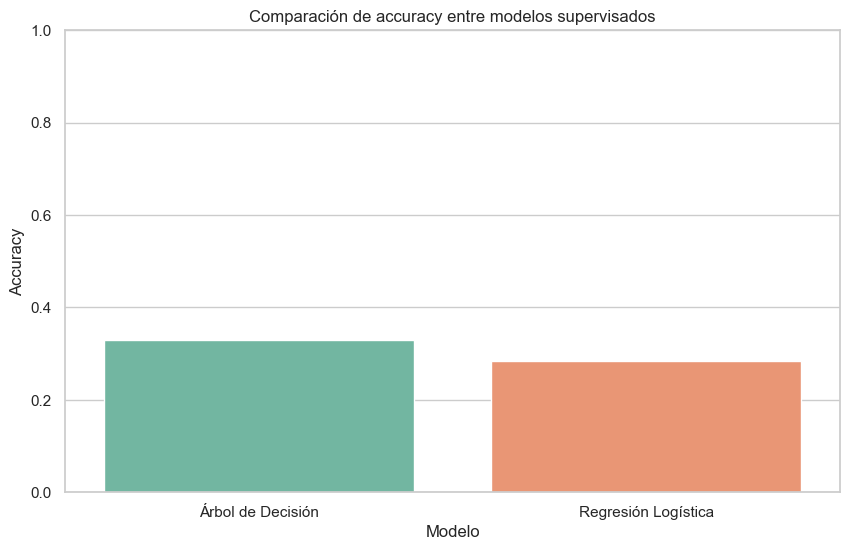

In [14]:
sns.barplot(data=comparacion, x="Modelo", y="Accuracy", palette="Set2")
plt.title("Comparación de accuracy entre modelos supervisados")
plt.ylim(0, 1)
plt.show()

In [15]:
print("Conclusiones iniciales:")
print("- El árbol de decisión permite interpretar fácilmente las decisiones del modelo.")
print("- La variable raíz muestra cuál fue el atributo más importante en la primera división.")
print("- La regresión logística sirve como modelo base de comparación.")
print("- El siguiente paso será evaluar más en detalle y luego optimizar hiperparámetros.")

Conclusiones iniciales:
- El árbol de decisión permite interpretar fácilmente las decisiones del modelo.
- La variable raíz muestra cuál fue el atributo más importante en la primera división.
- La regresión logística sirve como modelo base de comparación.
- El siguiente paso será evaluar más en detalle y luego optimizar hiperparámetros.
